# Engine-room flame metrics — `warm_M5` ventilation-timing comparison

Compares **3 cases** (mechanical ventilation starts at **20 / 40 / 60 s**) using the
Lan et al. 2023 Fig 9 / 10 flame-shape metrics from `plot_fig9_10.py`, computed from
the 3-D **HRRPUV** field (smoke3d).

All three runs were stopped by the 6 h SLURM time limit, so the analysis is capped at
**t ≤ 200 s** (common coverage: v40→221 s, v20→271 s, v60→279 s).

- **L_y** — flame y-projection span (bbox of max-z HRRPUV > THRESH)
- **H_f** — flame tip height (lowest z reaching 99 % of cumulative HRR)
- **θ_z** — tilt angle `arctan(√(Lx²+Ly²)/H_f)`

Curves are **block-averaged over 30 frames (steps)** — one plotted point per 30-frame
interval (non-overlapping), instead of a centred rolling mean.


In [1]:
import warnings; warnings.filterwarnings("ignore")
import logging;  logging.disable(logging.CRITICAL)
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import fdsreader

plt.rcParams.update({"axes.labelsize": 14, "axes.titlesize": 15,
                     "xtick.labelsize": 11, "ytick.labelsize": 11,
                     "legend.fontsize": 11})
print("fdsreader", fdsreader.__version__)

fdsreader 1.11.7


In [2]:
RES = Path("/shared/home/wel1come1234/workspace/FDS/Engineroom/Results")
OUT = Path("/shared/home/wel1come1234/workspace/FDS/Engineroom/Analysis/flame")
OUT.mkdir(parents=True, exist_ok=True)

# case dir -> (legend label, colour, HRR peak time s)  ordered by peak time.
# Vents run from t=0 in every case; the only varied knob is the HRR t^2
# time-to-peak (5/10/15/20 s).
CASES = {
    "peak05_M5": ("peak @5 s",  "#2980b9",  5),
    "peak10_M5": ("peak @10 s", "#27ae60", 10),
    "peak15_M5": ("peak @15 s", "#e67e22", 15),
    "peak20_M5": ("peak @20 s", "#8e44ad", 20),
}

TMAX    = 360.0            # full run coverage (all 4 runs reached T_END=360 s)
WIN     = (300.0, 360.0)   # steady-state averaging window (within TMAX)
THRESH  = 150.0            # kW/m3  HRRPUV flame-surface threshold (L_x, L_y)
FIRE_X  = (7.955, 8.845)   # fire footprint x (burner x-axis)
FIRE_Y  = (1.005, 1.895)   # fire footprint y (flame mesh band)
HF_FRAC = 0.99             # H_f cumulative-HRR fraction
BLOCK   = 30               # block-average interval: one point per 30 frames (steps)

# reference data (Lan et al. 2023, digitized): metric -> csv (time, value)
REF_FILES = {"Ly": "Fig9.csv", "Hf": "Fig10_1.csv", "theta": "Fig10_2.csv"}


In [3]:
def block_mean(t, arr, n):
    """Non-overlapping n-sample block average: one averaged point per n frames.
    Returns (block-centre time, block-mean value)."""
    t = np.asarray(t, float); arr = np.asarray(arr, float)
    nb = len(arr) // n
    if nb == 0:
        return np.array([np.nanmean(t)]), np.array([np.nanmean(arr)])
    tt = t[:nb * n].reshape(nb, n)
    aa = arr[:nb * n].reshape(nb, n)
    return np.nanmean(tt, axis=1), np.nanmean(aa, axis=1)


def flame_metrics(sim):
    """L_x, L_y, H_f from the 3D HRRPUV field over the fire y-band (Lan 2023 Fig 9/10)."""
    s3 = [s for s in sim.smoke_3d if "HRRPUV" in s.quantity.name.upper()][0]
    t  = np.array(s3.times)

    sel = [m for m in sim.meshes
           if m.coordinates["y"][0] < FIRE_Y[1] and m.coordinates["y"][-1] > FIRE_Y[0]]
    x_arr = np.unique(np.concatenate([m.coordinates["x"] for m in sel]))
    y_arr = np.unique(np.concatenate([m.coordinates["y"] for m in sel]))
    z_arr = np.unique(np.concatenate([m.coordinates["z"] for m in sel]))
    dz    = float(np.diff(z_arr).mean())

    P = np.zeros((len(t), len(x_arr), len(y_arr)))   # max_z HRRPUV  -> L_x, L_y
    B = np.zeros((len(t), len(x_arr), len(z_arr)))   # int HRRPUV dy -> H_f, centre
    for m in sel:
        d   = s3[m].data
        dy  = float(np.diff(m.coordinates["y"]).mean())
        pm  = d.max(axis=3)
        qy  = d.sum(axis=2) * dy
        ixg = np.clip(np.searchsorted(x_arr, m.coordinates["x"]), 0, len(x_arr) - 1)
        iyg = np.clip(np.searchsorted(y_arr, m.coordinates["y"]), 0, len(y_arr) - 1)
        izg = np.clip(np.searchsorted(z_arr, m.coordinates["z"]), 0, len(z_arr) - 1)
        for a, xg in enumerate(ixg):
            P[:, xg, iyg]  = np.maximum(P[:, xg, iyg], pm[:, a, :])
            B[:, xg, izg] += qy[:, a, :]

    XX, _   = np.meshgrid(x_arr, y_arr, indexing="ij")
    xc_burn = 0.5 * (FIRE_X[0] + FIRE_X[1])
    L_x = np.zeros(len(t)); L_y = np.zeros(len(t))
    for i in range(len(t)):
        mask = P[i] > THRESH
        if not mask.any():
            continue
        iy = np.where(mask.any(axis=0))[0]
        if len(iy) > 1:
            L_y[i] = y_arr[iy[-1]] - y_arr[iy[0]]
        w = P[i][mask]
        L_x[i] = abs((XX[mask] * w).sum() / w.sum() - xc_burn)

    A    = B.sum(axis=2) * dz
    H    = np.zeros(len(t)); xcen = np.full(len(t), np.nan)
    for i in range(len(t)):
        a = A[i]
        if a.sum() <= 0:
            continue
        xcen[i] = (x_arr * a).sum() / a.sum()
        ix      = int(np.argmin(np.abs(x_arr - xcen[i])))
        cum     = np.cumsum(B[i, ix]) * dz
        total   = cum[-1]
        if total > 0:
            iz   = int(np.searchsorted(cum, HF_FRAC * total))
            H[i] = z_arr[min(iz, len(z_arr) - 1)]
    return t, L_x, L_y, H

In [4]:
results = {}
for case, (label, color, vs) in CASES.items():
    print(f"loading {case} ({label}) ...", flush=True)
    sim = fdsreader.Simulation(str(RES / case))
    t, Lx, Ly, Hf = flame_metrics(sim)
    Lxy   = np.sqrt(Lx**2 + Ly**2)
    theta = np.full(len(t), np.nan)
    gz    = Hf > 0.05
    theta[gz] = np.degrees(np.arctan2(Lxy[gz], Hf[gz]))
    results[case] = dict(label=label, color=color, peak=vs, t=t,
                         Ly=Ly, Hf=Hf, theta=theta)
    print(f"  -> {len(t)} frames, t=[{t.min():.1f},{t.max():.1f}]s")

loading peak05_M5 (peak @5 s) ...


  -> 1001 frames, t=[0.0,360.0]s
loading peak10_M5 (peak @10 s) ...


  -> 1001 frames, t=[0.0,360.0]s
loading peak15_M5 (peak @15 s) ...


  -> 1001 frames, t=[0.0,360.0]s
loading peak20_M5 (peak @20 s) ...


  -> 1001 frames, t=[0.0,360.0]s


In [5]:
# steady-state averages over WIN (within the 200 s cutoff)
print(f"Steady-state averages over {WIN[0]:.0f}-{WIN[1]:.0f} s:\n")
print(f"{'case':12s} {'L_y [m]':>9s} {'H_f [m]':>9s} {'theta_z [deg]':>14s}")
for case, r in results.items():
    w = (r["t"] >= WIN[0]) & (r["t"] <= WIN[1])
    print(f"{r['label']:12s} {np.nanmean(r['Ly'][w]):9.3f} "
          f"{np.nanmean(r['Hf'][w]):9.3f} {np.nanmean(r['theta'][w]):14.1f}")

Steady-state averages over 300-360 s:

case           L_y [m]   H_f [m]  theta_z [deg]
peak @5 s        1.164     0.866           53.8
peak @10 s       1.111     0.840           53.5
peak @15 s       1.129     0.812           54.3
peak @20 s       1.153     0.841           54.2


In [6]:
def load_ref(name):
    p = OUT / name
    return np.loadtxt(p, delimiter=",") if p.exists() else None

refs = {k: load_ref(v) for k, v in REF_FILES.items()}
for k, a in refs.items():
    info = "none" if a is None else f"{a.shape[0]} pts, t=[{a[:,0].min():.0f},{a[:,0].max():.0f}]s"
    print(f"ref {k:6s}: {info}")

ref Ly    : 55 pts, t=[1,299]s
ref Hf    : 46 pts, t=[2,299]s
ref theta : 47 pts, t=[1,299]s


-> /shared/home/wel1come1234/workspace/FDS/Engineroom/Analysis/flame/cmp_fig9_Ly.png
-> /shared/home/wel1come1234/workspace/FDS/Engineroom/Analysis/flame/cmp_fig10_1_Hf.png


-> /shared/home/wel1come1234/workspace/FDS/Engineroom/Analysis/flame/cmp_fig10_2_thetaz.png


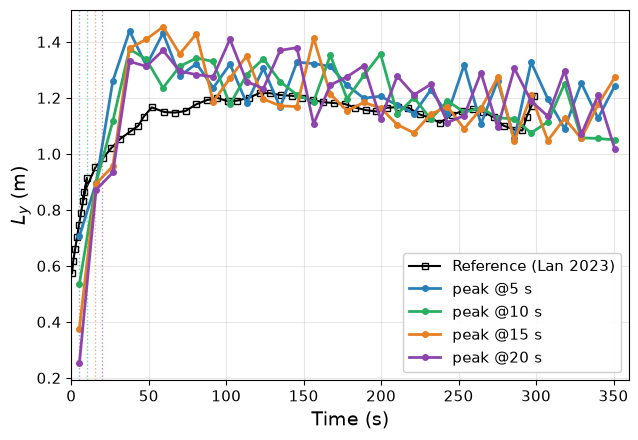

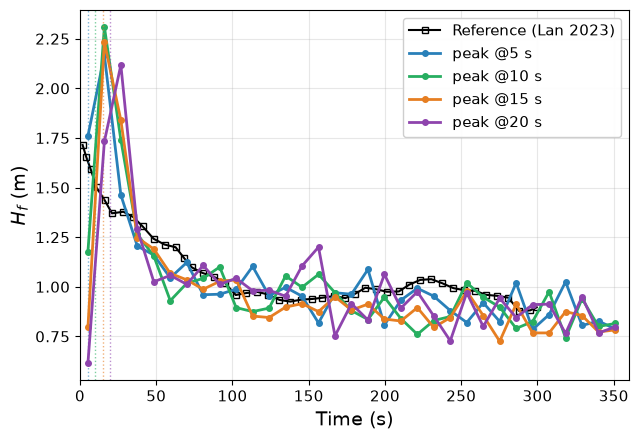

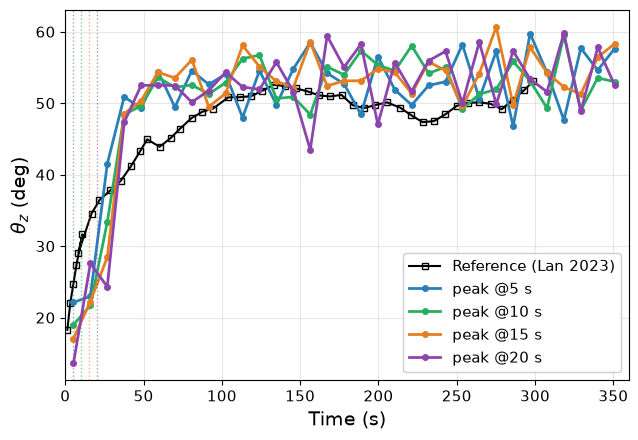

In [7]:
def overlay(key, refkey, ylabel, fname):
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ref = refs.get(refkey)
    if ref is not None:
        ax.plot(ref[:, 0], ref[:, 1], "k-s", lw=1.5, ms=4, mfc="none",
                label="Reference (Lan 2023)")
    for case, r in results.items():
        m = r["t"] <= TMAX
        tb, vb = block_mean(r["t"][m], r[key][m], BLOCK)
        ax.plot(tb, vb, "-o", color=r["color"], lw=2.0, ms=4, label=r["label"])
        ax.axvline(r["peak"], color=r["color"], ls=":", lw=1.0, alpha=0.6)
    ax.set_xlabel("Time (s)"); ax.set_ylabel(ylabel)
    ax.set_xlim(0, TMAX); ax.grid(alpha=0.3)
    ax.legend(loc="best", framealpha=0.95)
    fig.tight_layout(); fig.savefig(OUT / fname, dpi=150)
    print("->", OUT / fname)
    return fig

overlay("Ly",    "Ly",    r"$L_y$ (m)",      "cmp_fig9_Ly.png")
overlay("Hf",    "Hf",    r"$H_f$ (m)",      "cmp_fig10_1_Hf.png")
overlay("theta", "theta", r"$\theta_z$ (deg)", "cmp_fig10_2_thetaz.png")
plt.show()

-> /shared/home/wel1come1234/workspace/FDS/Engineroom/Analysis/flame/cmp_fig9_10_panel.png


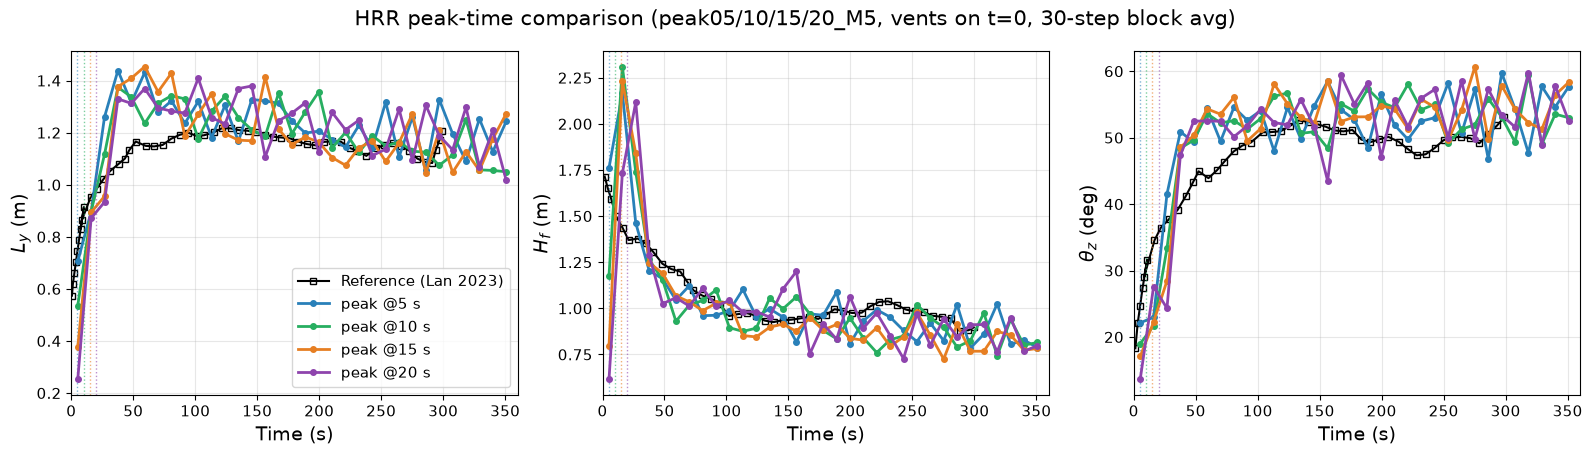

In [8]:
# combined 1x3 overview panel
fig, axs = plt.subplots(1, 3, figsize=(16, 4.6))
panels = [("Ly", "Ly", r"$L_y$ (m)"), ("Hf", "Hf", r"$H_f$ (m)"),
          ("theta", "theta", r"$\theta_z$ (deg)")]
for ax, (key, refkey, yl) in zip(axs, panels):
    ref = refs.get(refkey)
    if ref is not None:
        ax.plot(ref[:, 0], ref[:, 1], "k-s", lw=1.5, ms=4, mfc="none",
                label="Reference (Lan 2023)")
    for case, r in results.items():
        m = r["t"] <= TMAX
        tb, vb = block_mean(r["t"][m], r[key][m], BLOCK)
        ax.plot(tb, vb, "-o", color=r["color"], lw=2.0, ms=4, label=r["label"])
        ax.axvline(r["peak"], color=r["color"], ls=":", lw=1.0, alpha=0.6)
    ax.set_xlabel("Time (s)"); ax.set_ylabel(yl); ax.set_xlim(0, TMAX); ax.grid(alpha=0.3)
axs[0].legend(loc="best")
fig.suptitle("HRR peak-time comparison (peak05/10/15/20_M5, vents on t=0, 30-step block avg)", fontsize=15)
fig.tight_layout(); fig.savefig(OUT / "cmp_fig9_10_panel.png", dpi=150)
print("->", OUT / "cmp_fig9_10_panel.png")
plt.show()